In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [13]:
NUM_GATES = 6
NUM_ROWS = 3
SENSORS_PER_ROW = 6
NUM_SENSORS = NUM_ROWS * SENSORS_PER_ROW
SEQ_LEN = 60
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [14]:
def simulate_people_seq(num_samples=1):
    X_data, Y_data = [], []
    for _ in range(num_samples):
        X = np.zeros((SEQ_LEN, NUM_SENSORS))
        Y = np.zeros((SEQ_LEN, NUM_GATES))
        people = []
        for _ in range(random.randint(3, 8)):
            p_type = random.choice(["walker", "diagonal", "wanderer"])
            gate_target = random.randint(0, NUM_GATES - 1) if p_type != "wanderer" else None
            col_pos = gate_target if gate_target is not None else random.randint(0, NUM_GATES - 1)
            people.append({"type": p_type, "row": 0, "col": col_pos, "gate": gate_target})
        for t in range(SEQ_LEN):
            for p in people:
                if random.random() < 0.4:
                    if p["type"] == "walker":
                        p["row"] = min(NUM_ROWS - 1, p["row"] + 1)
                    elif p["type"] == "diagonal":
                        p["row"] = min(NUM_ROWS - 1, p["row"] + 1)
                        p["col"] = min(NUM_GATES - 1, max(0, p["col"] + random.choice([-1, 1])))
                    elif p["type"] == "wanderer":
                        p["row"] = min(NUM_ROWS - 1, max(0, p["row"] + random.choice([-1, 1])))
                        p["col"] = min(NUM_GATES - 1, max(0, p["col"] + random.choice([-1, 1])))
                sensor_index = p["row"] * SENSORS_PER_ROW + p["col"]
                X[t, sensor_index] = 1
                if p["row"] == NUM_ROWS - 1 and p["gate"] is not None and p["col"] == p["gate"]:
                    Y[t, p["gate"]] = 1
        X_data.append(X)
        Y_data.append(Y)
    return np.array(X_data, dtype=np.float32), np.array(Y_data, dtype=np.float32)


In [15]:
class GatePredictorUltraTinyTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        embed_dim = 16
        num_heads = 2   # ✅ fixed (avoid warning)
        num_layers = 1
        ff_dim = 32
        self.input_fc = nn.Linear(NUM_SENSORS, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(embed_dim, NUM_GATES)
    def forward(self, x):
        return self.fc_out(self.transformer(self.input_fc(x)))

class GatePredictorBalancedTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        embed_dim = 32
        num_heads = 2
        num_layers = 2
        ff_dim = 64
        self.input_fc = nn.Linear(NUM_SENSORS, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(embed_dim, NUM_GATES)
    def forward(self, x):
        return self.fc_out(self.transformer(self.input_fc(x)))


In [16]:
# 🔹 CHOOSE ONE
model = GatePredictorUltraTinyTransformer().to(device)   # ✅ FAST
# model = GatePredictorBalancedTransformer().to(device)  # ✅ Better Accuracy

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=400, gamma=0.7)
loss_fn = nn.BCEWithLogitsLoss()


In [17]:
X_all, Y_all = simulate_people_seq(8000)
X_train, X_test, Y_train, Y_test = train_test_split(X_all, Y_all, test_size=0.2)

X_train, Y_train = torch.tensor(X_train).to(device), torch.tensor(Y_train).to(device)
X_test, Y_test = torch.tensor(X_test).to(device), torch.tensor(Y_test).to(device)


In [18]:
best_loss = float("inf")
for epoch in range(4000):
    idx = np.random.randint(0, len(X_train), 256)
    X, Y = X_train[idx], Y_train[idx]

    optimizer.zero_grad()
    out = model(X)
    loss = loss_fn(out, Y)
    loss.backward()
    optimizer.step()
    scheduler.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        torch.save(model.state_dict(), "gate_predictor.pth")

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Loss={loss.item():.6f}")

    if best_loss < 0.002:
        print(f"✅ Early Stop | Final Loss={best_loss:.6f}")
        break

print("✅ Training Done | Best Loss:", best_loss)


Epoch 0 | Loss=0.724014
Epoch 200 | Loss=0.280285
Epoch 400 | Loss=0.182914
Epoch 600 | Loss=0.155168
Epoch 800 | Loss=0.157652
Epoch 1000 | Loss=0.146449
Epoch 1200 | Loss=0.145204
Epoch 1400 | Loss=0.148532
Epoch 1600 | Loss=0.137000
Epoch 1800 | Loss=0.149515
Epoch 2000 | Loss=0.137214
Epoch 2200 | Loss=0.143311
Epoch 2400 | Loss=0.148641
Epoch 2600 | Loss=0.120582
Epoch 2800 | Loss=0.143302
Epoch 3000 | Loss=0.133001
Epoch 3200 | Loss=0.131310
Epoch 3400 | Loss=0.142039
Epoch 3600 | Loss=0.138668
Epoch 3800 | Loss=0.142084
✅ Training Done | Best Loss: 0.11905457079410553


In [19]:
model.load_state_dict(torch.load("gate_predictor.pth", map_location="cpu"))
model.eval()

with torch.no_grad():
    train_pred = torch.sigmoid(model(X_train)).cpu().numpy() > 0.5
    test_pred = torch.sigmoid(model(X_test)).cpu().numpy() > 0.5

train_acc = accuracy_score(Y_train.cpu().numpy().reshape(-1), train_pred.reshape(-1))
test_acc = accuracy_score(Y_test.cpu().numpy().reshape(-1), test_pred.reshape(-1))

print(f"📊 Train Accuracy: {train_acc:.3f}")
print(f"📊 Test Accuracy : {test_acc:.3f}")

if train_acc - test_acc > 0.1:
    print("⚠️ Model is Overfitting")
elif train_acc < 0.8 and test_acc < 0.8:
    print("⚠️ Model is Underfitting")
else:
    print("✅ Model Training is Balanced")


📊 Train Accuracy: 0.951
📊 Test Accuracy : 0.949
✅ Model Training is Balanced


In [20]:
model.load_state_dict(torch.load("gate_predictor.pth", map_location="cpu"))
model.eval()

with torch.no_grad():
    train_pred = torch.sigmoid(model(X_train)).cpu().numpy() > 0.5
    test_pred = torch.sigmoid(model(X_test)).cpu().numpy() > 0.5

train_acc = accuracy_score(Y_train.cpu().numpy().reshape(-1), train_pred.reshape(-1))
test_acc = accuracy_score(Y_test.cpu().numpy().reshape(-1), test_pred.reshape(-1))

print(f"📊 Train Accuracy: {train_acc:.3f}")
print(f"📊 Test Accuracy : {test_acc:.3f}")

if train_acc - test_acc > 0.1:
    print("⚠️ Model is Overfitting")
elif train_acc < 0.8 and test_acc < 0.8:
    print("⚠️ Model is Underfitting")
else:
    print("✅ Model Training is Balanced")


📊 Train Accuracy: 0.951
📊 Test Accuracy : 0.949
✅ Model Training is Balanced


In [21]:
online_learning_loop(model, total_minutes=5, train_epochs_per_minute=20)


NameError: name 'online_learning_loop' is not defined

Epoch 0 | Loss=0.791214
Epoch 200 | Loss=0.424748
Epoch 400 | Loss=0.321969
Epoch 600 | Loss=0.307629
Epoch 800 | Loss=0.299922
Epoch 1000 | Loss=0.298569
Epoch 1200 | Loss=0.296478
Epoch 1400 | Loss=0.289296
Epoch 1600 | Loss=0.289795
Epoch 1800 | Loss=0.279811
Epoch 2000 | Loss=0.294245
Epoch 2200 | Loss=0.295734
Epoch 2400 | Loss=0.285032
Epoch 2600 | Loss=0.288905
Epoch 2800 | Loss=0.280619
Epoch 3000 | Loss=0.288498
Epoch 3200 | Loss=0.287656
Epoch 3400 | Loss=0.282692
Epoch 3600 | Loss=0.291886
Epoch 3800 | Loss=0.288561
✅ Training Done | Best Loss: 0.2671774923801422
📊 Train Accuracy: 0.898
📊 Test Accuracy : 0.898
✅ Balanced Training

🕒 Minute 1


C:\Users\Mriganga\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128229 (\N{INBOX TRAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


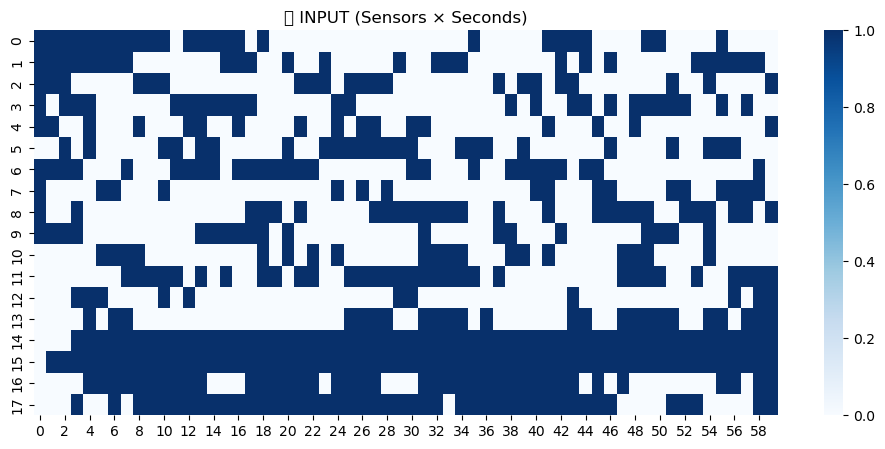

C:\Users\Mriganga\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128228 (\N{OUTBOX TRAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


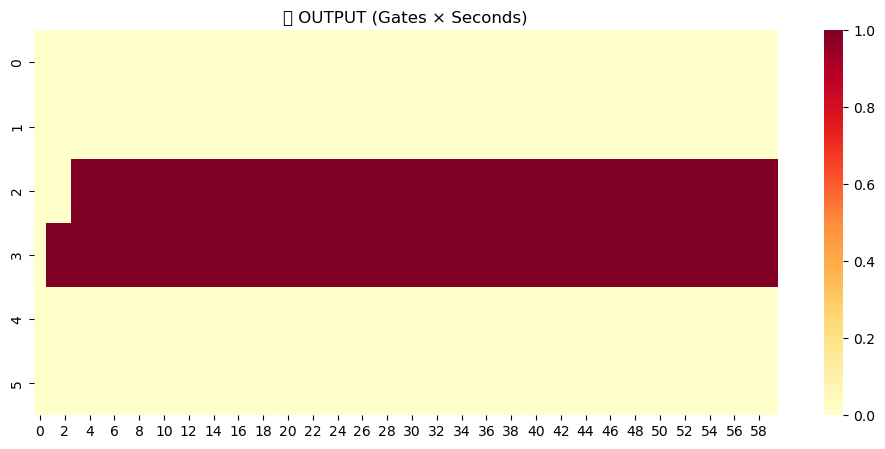

📊 Accuracy=0.903 | Precision=0.871 | Recall=0.835 | F1=0.852

🕒 Minute 2


C:\Users\Mriganga\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128229 (\N{INBOX TRAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


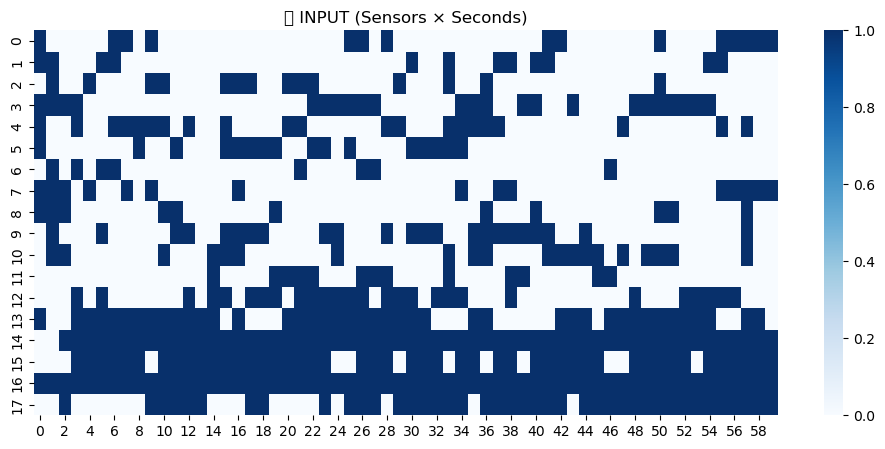

C:\Users\Mriganga\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128228 (\N{OUTBOX TRAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


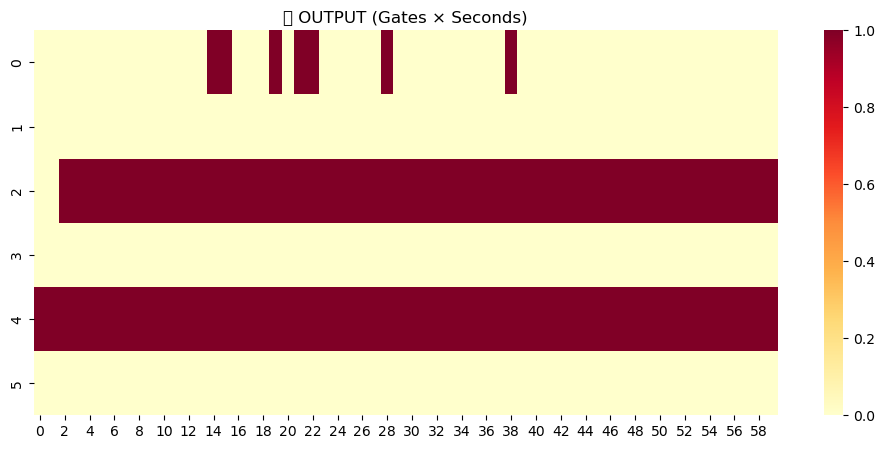

📊 Accuracy=0.825 | Precision=0.776 | Recall=0.735 | F1=0.755

🕒 Minute 3


C:\Users\Mriganga\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128229 (\N{INBOX TRAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


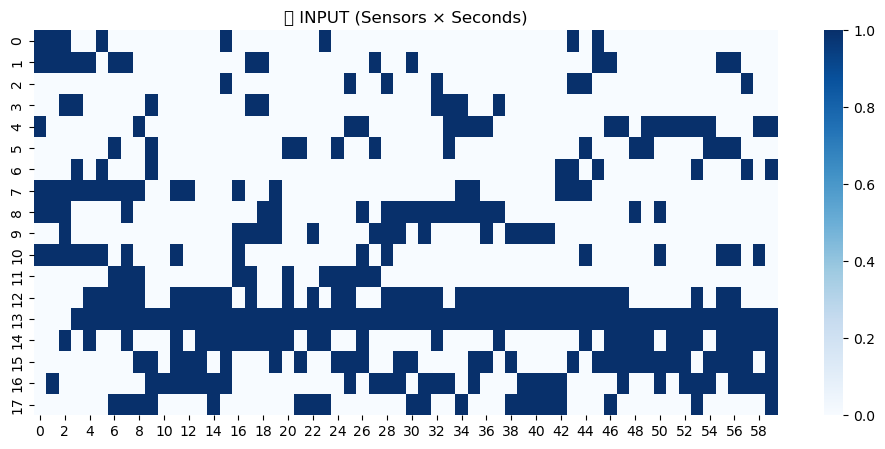

C:\Users\Mriganga\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128228 (\N{OUTBOX TRAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


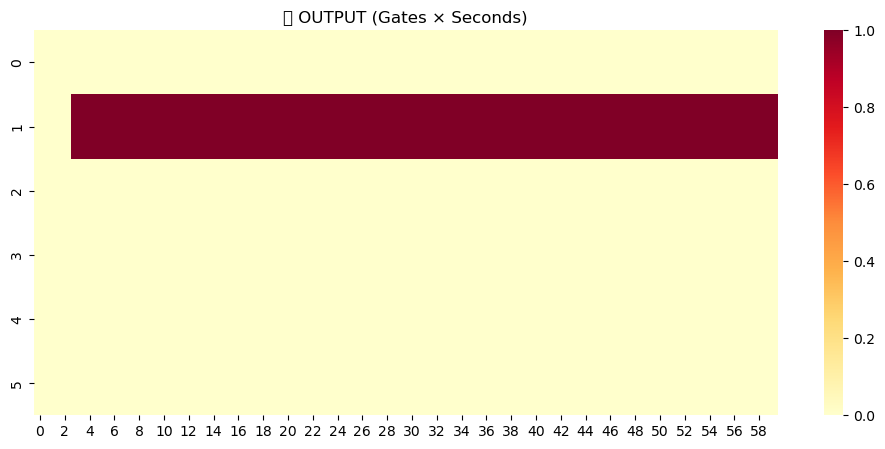

📊 Accuracy=0.933 | Precision=0.877 | Recall=0.746 | F1=0.806


In [23]:
!pip install torch torchvision pandas scikit-learn matplotlib seaborn

import torch, torch.nn as nn, torch.optim as optim
import numpy as np, pandas as pd, random, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 🔹 CONFIG
NUM_GATES, NUM_ROWS, SENSORS_PER_ROW, SEQ_LEN = 6, 3, 6, 60
NUM_SENSORS = NUM_ROWS * SENSORS_PER_ROW
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🔹 DATA SIMULATION
def simulate_people_seq(num_samples=1):
    X_data, Y_data = [], []
    for _ in range(num_samples):
        X, Y = np.zeros((SEQ_LEN, NUM_SENSORS)), np.zeros((SEQ_LEN, NUM_GATES))
        people = []

        for _ in range(random.randint(5, 12)):  # More people
            p_type = random.choice(["walker", "diagonal", "wanderer", "random_trigger"])
            gate_target = random.randint(0, NUM_GATES - 1) if p_type != "wanderer" else None
            col_pos = gate_target if gate_target is not None else random.randint(0, NUM_GATES - 1)
            people.append({"type": p_type, "row": 0, "col": col_pos, "gate": gate_target})

        for t in range(SEQ_LEN):
            # 🔹 Random sensor noise
            for _ in range(random.randint(0, 3)):
                X[t, random.randint(0, NUM_SENSORS-1)] = 1  # Random trigger

            for p in people:
                if random.random() < 0.5:
                    if p["type"] == "walker":
                        p["row"] = min(NUM_ROWS - 1, p["row"] + 1)
                    elif p["type"] == "diagonal":
                        p["row"] = min(NUM_ROWS - 1, p["row"] + 1)
                        p["col"] = min(NUM_GATES - 1, max(0, p["col"] + random.choice([-1, 1])))
                    elif p["type"] == "wanderer":
                        p["row"] = min(NUM_ROWS - 1, max(0, p["row"] + random.choice([-1, 1])))
                        p["col"] = min(NUM_GATES - 1, max(0, p["col"] + random.choice([-1, 1])))
                    elif p["type"] == "random_trigger":
                        p["row"] = random.randint(0, NUM_ROWS-1)
                        p["col"] = random.randint(0, NUM_GATES-1)

                sensor_index = p["row"] * SENSORS_PER_ROW + p["col"]
                X[t, sensor_index] = 1

                # 🔹 Sometimes gate does not open (real-world failure)
                if p["row"] == NUM_ROWS - 1 and p["gate"] is not None and p["col"] == p["gate"]:
                    if random.random() > 0.2:  # 80% chance gate opens
                        Y[t, p["gate"]] = 1

        X_data.append(X)
        Y_data.append(Y)
    return np.array(X_data, dtype=np.float32), np.array(Y_data, dtype=np.float32)


# 🔹 MODEL
class GatePredictorUltraTinyTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        embed_dim,num_heads,num_layers,ff_dim=16,2,1,32
        self.input_fc=nn.Linear(NUM_SENSORS,embed_dim)
        layer=nn.TransformerEncoderLayer(d_model=embed_dim,nhead=num_heads,
                                         dim_feedforward=ff_dim,batch_first=True)
        self.transformer=nn.TransformerEncoder(layer,num_layers=num_layers)
        self.fc_out=nn.Linear(embed_dim,NUM_GATES)
    def forward(self,x):
        return self.fc_out(self.transformer(self.input_fc(x)))

model=GatePredictorUltraTinyTransformer().to(device)
opt=optim.AdamW(model.parameters(),lr=0.001,weight_decay=0.01)
sched=optim.lr_scheduler.StepLR(opt,step_size=400,gamma=0.7)
loss_fn=nn.BCEWithLogitsLoss()

# 🔹 TRAIN/TEST SPLIT
X_all,Y_all=simulate_people_seq(8000)
Xtr,Xte,Ytr,Yte=train_test_split(X_all,Y_all,test_size=0.2)
Xtr,Ytr=torch.tensor(Xtr).to(device),torch.tensor(Ytr).to(device)
Xte,Yte=torch.tensor(Xte).to(device),torch.tensor(Yte).to(device)

# 🔹 TRAIN
best=float("inf")
for epoch in range(4000):
    idx=np.random.randint(0,len(Xtr),256)
    X,Y=Xtr[idx],Ytr[idx]
    opt.zero_grad(); out=model(X); loss=loss_fn(out,Y)
    loss.backward(); opt.step(); sched.step()
    if loss.item()<best:
        best=loss.item(); torch.save(model.state_dict(),"gate_predictor.pth")
    if epoch%200==0: print(f"Epoch {epoch} | Loss={loss.item():.6f}")
    if best<0.002: 
        print(f"✅ Early Stop | Final Loss={best:.6f}"); break

print("✅ Training Done | Best Loss:",best)

# 🔹 EVALUATE
model.load_state_dict(torch.load("gate_predictor.pth",map_location="cpu"))
model.eval()
with torch.no_grad():
    train_pred=(torch.sigmoid(model(Xtr)).cpu().numpy()>0.5)
    test_pred=(torch.sigmoid(model(Xte)).cpu().numpy()>0.5)

train_acc=accuracy_score(Ytr.cpu().numpy().reshape(-1),train_pred.reshape(-1))
test_acc=accuracy_score(Yte.cpu().numpy().reshape(-1),test_pred.reshape(-1))

print(f"📊 Train Accuracy: {train_acc:.3f}")
print(f"📊 Test Accuracy : {test_acc:.3f}")
if train_acc-test_acc>0.1: print("⚠️ Overfitting")
elif train_acc<0.8 and test_acc<0.8: print("⚠️ Underfitting")
else: print("✅ Balanced Training")

# 🔹 ONLINE LEARNING FUNCTION
def evaluate(y_true,y_pred):
    y_true,y_pred=y_true.reshape(-1),y_pred.reshape(-1)
    return (
        accuracy_score(y_true,y_pred),
        precision_score(y_true,y_pred,zero_division=0),
        recall_score(y_true,y_pred,zero_division=0),
        f1_score(y_true,y_pred,zero_division=0)
    )

def online_learning_loop(model,total_minutes=3,train_epochs_per_minute=10):
    X,Y=simulate_people_seq(1); curX,curY=X,Y
    opt=optim.AdamW(model.parameters(),lr=0.0005,weight_decay=0.01)
    lf=nn.BCEWithLogitsLoss()

    for m in range(1,total_minutes+1):
        print(f"\n🕒 Minute {m}")
        plt.figure(figsize=(12,5))
        sns.heatmap(curX[0].T,cmap="Blues")
        plt.title("📥 INPUT (Sensors × Seconds)")
        plt.show()

        with torch.no_grad(): pred=torch.sigmoid(model(torch.tensor(curX)))
        pred_bin=(pred.numpy()>0.5).astype(int)

        plt.figure(figsize=(12,5))
        sns.heatmap(pred_bin[0].T,cmap="YlOrRd")
        plt.title("📤 OUTPUT (Gates × Seconds)")
        plt.show()

        acc,prec,rec,f1=evaluate(curY,pred_bin)
        print(f"📊 Accuracy={acc:.3f} | Precision={prec:.3f} | Recall={rec:.3f} | F1={f1:.3f}")

        newX,newY=simulate_people_seq(1)
        for _ in range(train_epochs_per_minute):
            opt.zero_grad(); out=model(torch.tensor(newX))
            loss=lf(out,torch.tensor(newY)); loss.backward(); opt.step()

        torch.save(model.state_dict(),"gate_predictor.pth")
        curX,curY=newX,newY

# 🔹 RUN ONLINE LEARNING
online_learning_loop(model,total_minutes=3,train_epochs_per_minute=10)


In [24]:
torch.save(model.state_dict(), "gate_predictor.pth")


In [25]:
import torch
from torch.quantization import quantize_dynamic

# ✅ Load your trained model
model.eval()

# ✅ Quantize (reduce precision of Linear layers)
quantized_model = quantize_dynamic(model, {torch.nn.Linear}, dtype=torch.qint8)

# ✅ Save smaller model
torch.save(quantized_model.state_dict(), "gate_predictor_quantized.pth")

print("✅ Quantized model saved as gate_predictor_quantized.pth")


✅ Quantized model saved as gate_predictor_quantized.pth
